# Centralized Baseline Models
**Project:** Quantum-Inspired Federated IDS for IoT  
**Dataset:** CIC-IoT-2023 — 34 classes (augmented, 5.7M samples)  
**Objective:** Establish strong centralized baselines before Federated Learning  
**Author:** SAIFBKKK | **Date:** 2/26/2026

---

## 🎯 Purpose of This Notebook

Before introducing Federated Learning and Quantum-Inspired optimization, we need a **centralized reference point** — a set of classical ML models trained on the full dataset in a single-node setting.

These baselines serve two roles in the PFE:
1. **Performance ceiling** — the best a model can do with all data centralized
2. **Comparison baseline** — FL results will be evaluated *relative to* these numbers

---

## 🗺️ Pipeline Overview

```
┌──────────────────────────────────────────────────────────────────────┐
│              CENTRALIZED BASELINE PIPELINE                           │
│                                                                      │
│  📦 Load NPZ + Artifacts                                             │
│         ↓                                                            │
│  🔍 Sanity Checks  (NaN, Inf, shape, class balance)                 │
│         ↓                                                            │
│  ✂️  Stratified Subset  (400K rows for fast tuning)                  │
│         ↓                                                            │
│  🔧 RandomizedSearchCV + StratifiedKFold (3-fold)                   │
│         │                                                            │
│         ├── LogisticRegression   (linear baseline)                  │
│         ├── SGDClassifier        (scalable linear)                  │
│         ├── RandomForest         (tree ensemble)                    │
│         ├── HistGradientBoosting (fast boosting)                    │
│         └── MLPClassifier        (shallow neural net)               │
│         ↓                                                            │
│  📊 Compare on Validation Set  (Macro F1 primary metric)            │
│         ↓                                                            │
│  🏆 Re-train Best Model on FULL Train Set                           │
│         ↓                                                            │
│  📋 Final Evaluation on Test Set + Report                           │
│         ↓                                                            │
│  💾 Save Artifacts  (.pkl model, .json metrics)                     │
└──────────────────────────────────────────────────────────────────────┘
```

---

## ⚠️ Design Decisions

| Decision | Reason |
|----------|--------|
| **Tuning on 400K subset** | 5.7M rows × CV × multiple models = days of compute |
| **3-fold CV** (not 5) | Safer memory/time budget on large data |
| **Macro F1 as primary metric** | Dataset is imbalanced — accuracy is misleading |
| **Class weights = balanced** | BenignTraffic still underrepresented even after augmentation |
| **Re-train on full data** | Tuning subset finds best hyperparams; full data gives best model |

---

# SECTION 0 — Imports & Configuration

All paths and hyperparameters are defined here.  
**If you change machine or move files, only edit this section.**

In [1]:
import os
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── GPU Models ───────────────────────────────────────────────
from xgboost import XGBClassifier        # GPU via device="cuda"

# ── Sklearn Models ───────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    balanced_accuracy_score, ConfusionMatrixDisplay
)
from sklearn.linear_model    import LogisticRegression, SGDClassifier
from sklearn.ensemble        import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ── GPU Verification ─────────────────────────────────────────
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────
ROOT = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23"
PROC = os.path.join(ROOT, "processed")
ART  = os.path.join(ROOT, "artifacts")
RES  = os.path.join(ROOT, "results_baseline")
os.makedirs(RES, exist_ok=True)

# ── Tuning config ────────────────────────────────────────────
SUBSET_N = 400_000
N_SPLITS = 3
SCORING  = "f1_macro"
N_ITER   = 8
CLIP_VAL = 1e6

print("✅ Configuration loaded")
print(f"   Results will be saved to: {RES}")

CUDA available : True
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ Configuration loaded
   Results will be saved to: C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline


# SECTION 1 — Load Data & Artifacts

We load the **augmented** preprocessed dataset (`ciciot23_34class_augmented.npz`) which includes:
- ~5.7M training samples (with benign augmentation)
- 33 features (after dropping constant + correlated columns)
- 34 classes encoded as integers

We also load the label mapping to convert integer predictions back to human-readable attack names.

In [2]:
# ── Load NPZ ─────────────────────────────────────────────────
data = np.load(os.path.join(PROC, "ciciot23_34class_augmented.npz"))

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int64)
X_val   = data["X_val"].astype(np.float32)
y_val   = data["y_val"].astype(np.int64)
X_test  = data["X_test"].astype(np.float32)
y_test  = data["y_test"].astype(np.int64)

print("=== Dataset Loaded ===")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"  Classes : {np.unique(y_train).size}")

# ── Load label mapping ───────────────────────────────────────
with open(os.path.join(ART, "label_mapping_34.pkl"), "rb") as f:
    mapping = pickle.load(f)

label_to_id = mapping["label_to_id"]
id_to_label = mapping["id_to_label"]

# ── Load feature names ───────────────────────────────────────
with open(os.path.join(ART, "feature_names.pkl"), "rb") as f:
    feature_names = pickle.load(f)

print(f"\n  Features : {feature_names}")

=== Dataset Loaded ===
  X_train : (5718015, 33)  |  y_train : (5718015,)
  X_val   : (1176851, 33)    |  y_val   : (1176851,)
  X_test  : (1176851, 33)   |  y_test  : (1176851,)
  Classes : 34

  Features : ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'TCP', 'UDP', 'ICMP', 'IPv', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Covariance', 'Variance', 'Weight']


# SECTION 2 — Sanity Checks

Before training any model, we verify the data is clean and consistent.  
**Never skip this step** — silent NaN or Inf values cause models to silently produce garbage predictions.

We also apply a conservative clip at ±1e6 to handle any residual extreme values that could destabilize linear models.

In [3]:
def sanity_check(X, name):
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    print(f"[{name}]")
    print(f"  shape = {X.shape}")
    print(f"  min   = {np.min(X):.4f}  |  max = {np.max(X):.4f}  |  mean = {np.mean(X):.4f}")
    print(f"  NaN   = {nan_count}       |  Inf = {inf_count}")
    if nan_count > 0 or inf_count > 0:
        print(f"  ❌ WARNING: dirty values detected!")
    else:
        print(f"  ✅ Clean")

sanity_check(X_train, "X_train")
sanity_check(X_val,   "X_val")
sanity_check(X_test,  "X_test")

[X_train]
  shape = (5718015, 33)
  min   = -271.6713  |  max = 1132070528.0000  |  mean = 11683.5156
  NaN   = 0       |  Inf = 0
  ✅ Clean
[X_val]
  shape = (1176851, 33)
  min   = -305.2274  |  max = 102129728.0000  |  mean = 836.5554
  NaN   = 0       |  Inf = 0
  ✅ Clean
[X_test]
  shape = (1176851, 33)
  min   = -305.2274  |  max = 57384764.0000  |  mean = 834.1314
  NaN   = 0       |  Inf = 0
  ✅ Clean


In [4]:
# ── Clip extreme values ──────────────────────────────────────
# Why: even after RobustScaler, some features may still have extreme outliers
# that can cause numerical issues in LogisticRegression and MLP.
# Clipping at ±1e6 has negligible impact on tree-based models.

X_train = np.clip(X_train, -CLIP_VAL, CLIP_VAL)
X_val   = np.clip(X_val,   -CLIP_VAL, CLIP_VAL)
X_test  = np.clip(X_test,  -CLIP_VAL, CLIP_VAL)

print(f"✅ Clipped to [{-CLIP_VAL:.0e}, {CLIP_VAL:.0e}]")
print(f"   New range — min: {X_train.min():.4f}  max: {X_train.max():.4f}")

✅ Clipped to [-1e+06, 1e+06]
   New range — min: -271.6713  max: 1000000.0000


# SECTION 3 — Stratified Subset for Hyperparameter Tuning

**Why not tune on the full 5.7M rows?**

With 5 models × 8 random search iterations × 3-fold CV = **120 full model fits**.  
On 5.7M rows, this would take days. We instead:

1. Create a **stratified subset of 400K rows** (preserves class distribution)
2. Use it to find the best hyperparameters for each model
3. Re-train the winner on the **full 5.7M rows** in Section 7

This is standard practice for large-scale ML (see: sklearn docs, Kaggle competitions).

In [5]:
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSET_N,
    stratify=y_train,
    random_state=SEED
)

print(f"Tuning subset : {X_sub.shape}")
print(f"Classes in subset : {np.unique(y_sub).size}  (should be 34)")

# Verify class distribution is preserved
train_dist = pd.Series(y_train).value_counts(normalize=True)
sub_dist   = pd.Series(y_sub).value_counts(normalize=True)
drift = (train_dist - sub_dist).abs().max()
print(f"Max class distribution drift : {drift:.5f}  (should be < 0.01 ✅)")

Tuning subset : (400000, 33)
Classes in subset : 34  (should be 34)
Max class distribution drift : 0.00000  (should be < 0.01 ✅)


# SECTION 4 — Evaluation Function

We define a single `evaluate_model()` function used consistently across all models.  

**Primary metric: Macro F1-score**  
Why: with 34 classes and strong imbalance, Macro F1 gives equal weight to all classes — including rare ones like BenignTraffic. Accuracy would be dominated by the majority attack classes.

In [6]:
def evaluate_model(model, X, y, name="set", verbose=True):
    """
    Evaluate a fitted model and return a metrics dictionary.
    
    Metrics returned:
        - accuracy           : overall correct predictions / total
        - balanced_accuracy  : mean recall per class (unweighted)
        - macro_f1           : F1 averaged equally across all 34 classes  ← PRIMARY
        - weighted_f1        : F1 weighted by class support
    """
    y_pred = model.predict(X)
    metrics = {
        "accuracy"          : round(float(accuracy_score(y, y_pred)), 4),
        "balanced_accuracy" : round(float(balanced_accuracy_score(y, y_pred)), 4),
        "macro_f1"          : round(float(f1_score(y, y_pred, average="macro")), 4),
        "weighted_f1"       : round(float(f1_score(y, y_pred, average="weighted")), 4),
    }
    if verbose:
        print(f"\n── [{name}] ──────────────────────────────")
        for k, v in metrics.items():
            star = " ← PRIMARY" if k == "macro_f1" else ""
            print(f"   {k:<22}: {v:.4f}{star}")
    return metrics

# SECTION 5 — Model Definitions & Search Spaces

We define **5 candidate models** covering different algorithmic families:

| # | Model | Family | Why include it |
|---|-------|--------|----------------|
| 1 | **LogisticRegression** | Linear | Fast reference, interpretable, lower bound |
| 2 | **SGDClassifier** | Linear (online) | Scales to millions of rows natively |
| 3 | **RandomForest** | Tree ensemble | Robust, handles non-linearity, feature importance |
| 4 | **XGBoost** | Boosting (GPU) | State-of-art on tabular, full CUDA acceleration |
| 5 | **MLPClassifier** | Neural Network | Shallow DL baseline, link to FL architecture |

All models use `class_weight="balanced"` to handle the remaining class imbalance.

In [7]:
# ── Model 1: Logistic Regression ─────────────────────────────
# Solver: 'saga' supports multinomial + large datasets + L1/L2/elasticnet
logreg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced",
    solver="saga",
    multi_class="multinomial",
    random_state=SEED
)
logreg_params = {
    "C": [0.1, 1.0, 3.0],
}

# ── Model 2: SGD Classifier ──────────────────────────────────
sgd = SGDClassifier(
    loss="log_loss",
    max_iter=20,
    n_jobs=-1,
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED
)
sgd_params = {
    "alpha"  : [1e-6, 1e-5, 1e-4],
    "penalty": ["l2", "elasticnet"],
}

# ── Model 3: Random Forest ───────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=SEED
)
rf_params = {
    "max_depth"        : [None, 20, 40],
    "min_samples_split": [2, 5, 10],
    "max_features"     : ["sqrt", 0.5],
}

# ── Model 4: XGBoost GPU (replaces HistGradientBoosting) ─────
# tree_method="hist" + device="cuda" = full GPU training on RTX 3050
# class_weight not supported → use sample_weight in fit()
hgb = XGBClassifier(
    tree_method="hist",
    device="cuda",
    n_estimators=400,
    eval_metric="mlogloss",
    random_state=SEED
)
hgb_params = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth"    : [6, 10, 20],
    "n_estimators" : [200, 400],
}

# ── Precompute sample_weight for XGBoost (no class_weight support) ──
sample_weight_sub   = compute_sample_weight("balanced", y_sub)
sample_weight_train = compute_sample_weight("balanced", y_train)

# ── Model 5: MLP Classifier ──────────────────────────────────
mlp = MLPClassifier(
    early_stopping=True,
    max_iter=30,
    random_state=SEED
)
mlp_params = {
    "hidden_layer_sizes": [(256, 128, 64), (256, 128), (128, 64)],
    "alpha"             : [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-3, 5e-4],
}

print("✅ All 5 models defined  (GPU: XGBoost | CPU: logreg, sgd, rf, mlp)")

✅ All 5 models defined  (GPU: XGBoost | CPU: logreg, sgd, rf, mlp)


# SECTION 6 — Hyperparameter Tuning (RandomizedSearchCV)

**Strategy:** `RandomizedSearchCV` samples `n_iter` random combinations from the search space,  
each evaluated with `StratifiedKFold(n_splits=3)` cross-validation on the 400K subset.

**Why RandomizedSearch and not GridSearch?**  
With large search spaces, RandomizedSearch finds good solutions faster — it's not exhaustive but near-optimal in practice (Bergstra & Bengio, 2012).

In [8]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

def run_random_search(model, params, X, y, name, n_iter=N_ITER, sample_weight=None):
    print(f"\n{'='*55}")
    print(f" Tuning: {name}")
    print(f" Search space: {params}")
    print(f" Iterations: {n_iter}  |  CV folds: {N_SPLITS}  |  Scoring: {SCORING}")
    print(f"{'='*55}")

    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=n_iter,
        scoring=SCORING,
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=SEED,
        return_train_score=True
    )

    t0 = time.time()
    # XGBoost needs sample_weight — sklearn models pass it as fit_params
    if sample_weight is not None:
        rs.fit(X, y, sample_weight=sample_weight)
    else:
        rs.fit(X, y)
    elapsed = (time.time() - t0) / 60

    print(f"\n  ✅ Done in {elapsed:.1f} min")
    print(f"  Best CV {SCORING} : {rs.best_score_:.4f}")
    print(f"  Best params      : {rs.best_params_}")

    return rs

In [9]:
searches = {}

searches["logreg"] = run_random_search(logreg, logreg_params, X_sub, y_sub, "LogisticRegression", n_iter=3)
searches["sgd"]    = run_random_search(sgd,    sgd_params,    X_sub, y_sub, "SGDClassifier",      n_iter=6)
searches["rf"]     = run_random_search(rf,     rf_params,     X_sub, y_sub, "RandomForest",       n_iter=8)
searches["hgb"]    = run_random_search(hgb,    hgb_params,    X_sub, y_sub, "XGBoost-GPU",        n_iter=8,
                                       sample_weight=sample_weight_sub)   # ← only XGBoost gets this
searches["mlp"]    = run_random_search(mlp,    mlp_params,    X_sub, y_sub, "MLPClassifier",      n_iter=8)

print("\n✅ All models tuned.")


 Tuning: LogisticRegression
 Search space: {'C': [0.1, 1.0, 3.0]}
 Iterations: 3  |  CV folds: 3  |  Scoring: f1_macro
Fitting 3 folds for each of 3 candidates, totalling 9 fits

  ✅ Done in 16.5 min
  Best CV f1_macro : 0.0705
  Best params      : {'C': 0.1}

 Tuning: SGDClassifier
 Search space: {'alpha': [1e-06, 1e-05, 0.0001], 'penalty': ['l2', 'elasticnet']}
 Iterations: 6  |  CV folds: 3  |  Scoring: f1_macro
Fitting 3 folds for each of 6 candidates, totalling 18 fits

  ✅ Done in 0.7 min
  Best CV f1_macro : 0.1297
  Best params      : {'penalty': 'elasticnet', 'alpha': 1e-05}

 Tuning: RandomForest
 Search space: {'max_depth': [None, 20, 40], 'min_samples_split': [2, 5, 10], 'max_features': ['sqrt', 0.5]}
 Iterations: 8  |  CV folds: 3  |  Scoring: f1_macro
Fitting 3 folds for each of 8 candidates, totalling 24 fits

  ✅ Done in 16.2 min
  Best CV f1_macro : 0.8213
  Best params      : {'min_samples_split': 2, 'max_features': 0.5, 'max_depth': 40}

 Tuning: XGBoost-GPU
 Search

# SECTION 7 — Comparison on Validation Set

We evaluate each tuned model's **best estimator** on the held-out validation set.  
The validation set was **never used during tuning** — it gives an unbiased estimate of generalization.

We rank models by **Macro F1** and select the winner for full re-training.

In [10]:
val_results = {}

for name, rs in searches.items():
    val_results[name] = evaluate_model(
        rs.best_estimator_, X_val, y_val,
        name=f"VAL/{name}"
    )

# ── Comparison table ─────────────────────────────────────────
print("\n" + "="*65)
print(" VALIDATION RESULTS — RANKED BY MACRO F1")
print("="*65)

results_df = pd.DataFrame(val_results).T
results_df = results_df.sort_values("macro_f1", ascending=False)
results_df.index.name = "model"
display(results_df.style.highlight_max(color="lightgreen").format("{:.4f}"))


── [VAL/logreg] ──────────────────────────────
   accuracy              : 0.0528
   balanced_accuracy     : 0.1054
   macro_f1              : 0.0381 ← PRIMARY
   weighted_f1           : 0.0394

── [VAL/sgd] ──────────────────────────────
   accuracy              : 0.3216
   balanced_accuracy     : 0.1613
   macro_f1              : 0.1332 ← PRIMARY
   weighted_f1           : 0.3334

── [VAL/rf] ──────────────────────────────
   accuracy              : 0.9593
   balanced_accuracy     : 0.5623
   macro_f1              : 0.5559 ← PRIMARY
   weighted_f1           : 0.9612

── [VAL/hgb] ──────────────────────────────
   accuracy              : 0.9272
   balanced_accuracy     : 0.5195
   macro_f1              : 0.5125 ← PRIMARY
   weighted_f1           : 0.9295

── [VAL/mlp] ──────────────────────────────
   accuracy              : 0.8561
   balanced_accuracy     : 0.3439
   macro_f1              : 0.3444 ← PRIMARY
   weighted_f1           : 0.8442

 VALIDATION RESULTS — RANKED BY MACRO F1


,accuracy,balanced_accuracy,macro_f1,weighted_f1
model,,,,
rf,0.9593,0.5623,0.5559,0.9612
hgb,0.9272,0.5195,0.5125,0.9295
mlp,0.8561,0.3439,0.3444,0.8442
sgd,0.3216,0.1613,0.1332,0.3334
logreg,0.0528,0.1054,0.0381,0.0394


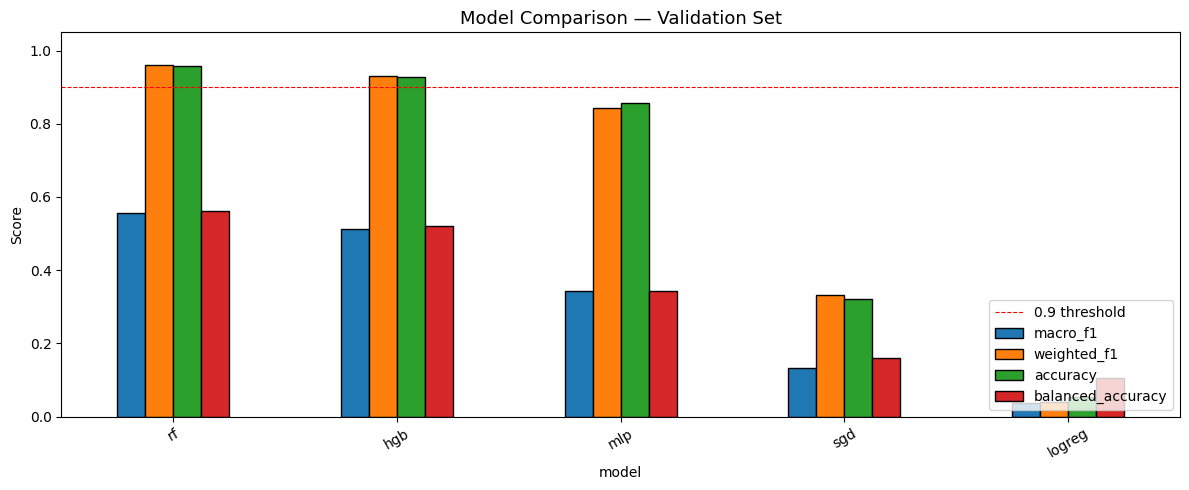


🏆 Best model on validation: RF  (Macro F1 = 0.5559)


In [11]:
# ── Bar chart comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

results_df[["macro_f1", "weighted_f1", "accuracy", "balanced_accuracy"]].plot(
    kind="bar", ax=ax, edgecolor="black"
)
ax.set_title("Model Comparison — Validation Set", fontsize=13)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color="red", linestyle="--", linewidth=0.8, label="0.9 threshold")
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(RES, "model_comparison_val.png"), dpi=150)
plt.show()

best_name = results_df.index[0]
print(f"\n🏆 Best model on validation: {best_name.upper()}  "
      f"(Macro F1 = {results_df.loc[best_name, 'macro_f1']:.4f})")

# SECTION 8 — Re-train Best Model on Full Training Set

The winning model is re-trained from scratch using its **best hyperparameters** on the **full 5.7M training rows**.

Why re-train instead of using the tuning model directly?
- The tuning model was fitted on only 400K rows (the subset)
- Re-training on full data gives the model maximum information
- This is the model that will be **saved and used as baseline** in the report

In [12]:
best_estimator = searches[best_name].best_estimator_

print(f"Re-training {best_name.upper()} on full train set ({X_train.shape[0]:,} rows)...")
print(f"Best hyperparameters: {searches[best_name].best_params_}")

t0 = time.time()
# XGBoost needs sample_weight — other models use class_weight internally
if best_name == "hgb":
    best_estimator.fit(X_train, y_train, sample_weight=sample_weight_train)
else:
    best_estimator.fit(X_train, y_train)
elapsed = (time.time() - t0) / 60

print(f"\n✅ Full training completed in {elapsed:.1f} min")

Re-training RF on full train set (5,718,015 rows)...
Best hyperparameters: {'min_samples_split': 2, 'max_features': 0.5, 'max_depth': 40}

✅ Full training completed in 20.8 min


# SECTION 9 — Final Evaluation on Test Set

The test set has been **untouched throughout the entire pipeline** — it was never used for tuning or validation.  
These are the **final numbers that go into the PFE report**.

We report:
- Global metrics (accuracy, Macro F1, etc.)
- Per-class classification report
- Confusion matrix

In [13]:
# ── Global metrics ───────────────────────────────────────────
test_metrics = evaluate_model(
    best_estimator, X_test, y_test,
    name=f"TEST / {best_name.upper()} (FINAL)"
)

# Also evaluate on val for comparison
val_final = evaluate_model(
    best_estimator, X_val, y_val,
    name=f"VAL  / {best_name.upper()} (after full retrain)"
)

# Check for overfitting: val ≈ test is healthy
gap = abs(val_final["macro_f1"] - test_metrics["macro_f1"])
print(f"\nVal/Test Macro F1 gap : {gap:.4f}  ", end="")
print("✅ Healthy" if gap < 0.02 else "⚠️ Possible overfitting")


── [TEST / RF (FINAL)] ──────────────────────────────
   accuracy              : 0.9518
   balanced_accuracy     : 0.5186
   macro_f1              : 0.5106 ← PRIMARY
   weighted_f1           : 0.9547

── [VAL  / RF (after full retrain)] ──────────────────────────────
   accuracy              : 0.9518
   balanced_accuracy     : 0.5227
   macro_f1              : 0.5083 ← PRIMARY
   weighted_f1           : 0.9548

Val/Test Macro F1 gap : 0.0023  ✅ Healthy


In [14]:
# ── Per-class classification report ─────────────────────────
y_pred = best_estimator.predict(X_test)
class_names = [id_to_label[i] for i in range(34)]

report_str  = classification_report(y_test, y_pred, target_names=class_names)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

print("\n=== Per-Class Report ===")
print(report_str)


=== Per-Class Report ===
                         precision    recall  f1-score   support

       Backdoor_Malware       0.50      0.01      0.02        89
          BenignTraffic       0.72      0.50      0.59     27709
       BrowserHijacking       1.00      0.05      0.10       134
       CommandInjection       0.00      0.00      0.00       119
 DDoS-ACK_Fragmentation       0.99      0.88      0.93      7292
        DDoS-HTTP_Flood       0.14      1.00      0.24       709
        DDoS-ICMP_Flood       1.00      1.00      1.00    180447
DDoS-ICMP_Fragmentation       0.93      0.99      0.96     11402
      DDoS-PSHACK_Flood       1.00      1.00      1.00    103326
       DDoS-RSTFINFlood       1.00      1.00      1.00    101819
         DDoS-SYN_Flood       1.00      1.00      1.00    102208
         DDoS-SlowLoris       0.22      0.01      0.02       622
DDoS-SynonymousIP_Flood       0.99      0.99      0.99     90480
         DDoS-TCP_Flood       1.00      1.00      1.00    11373

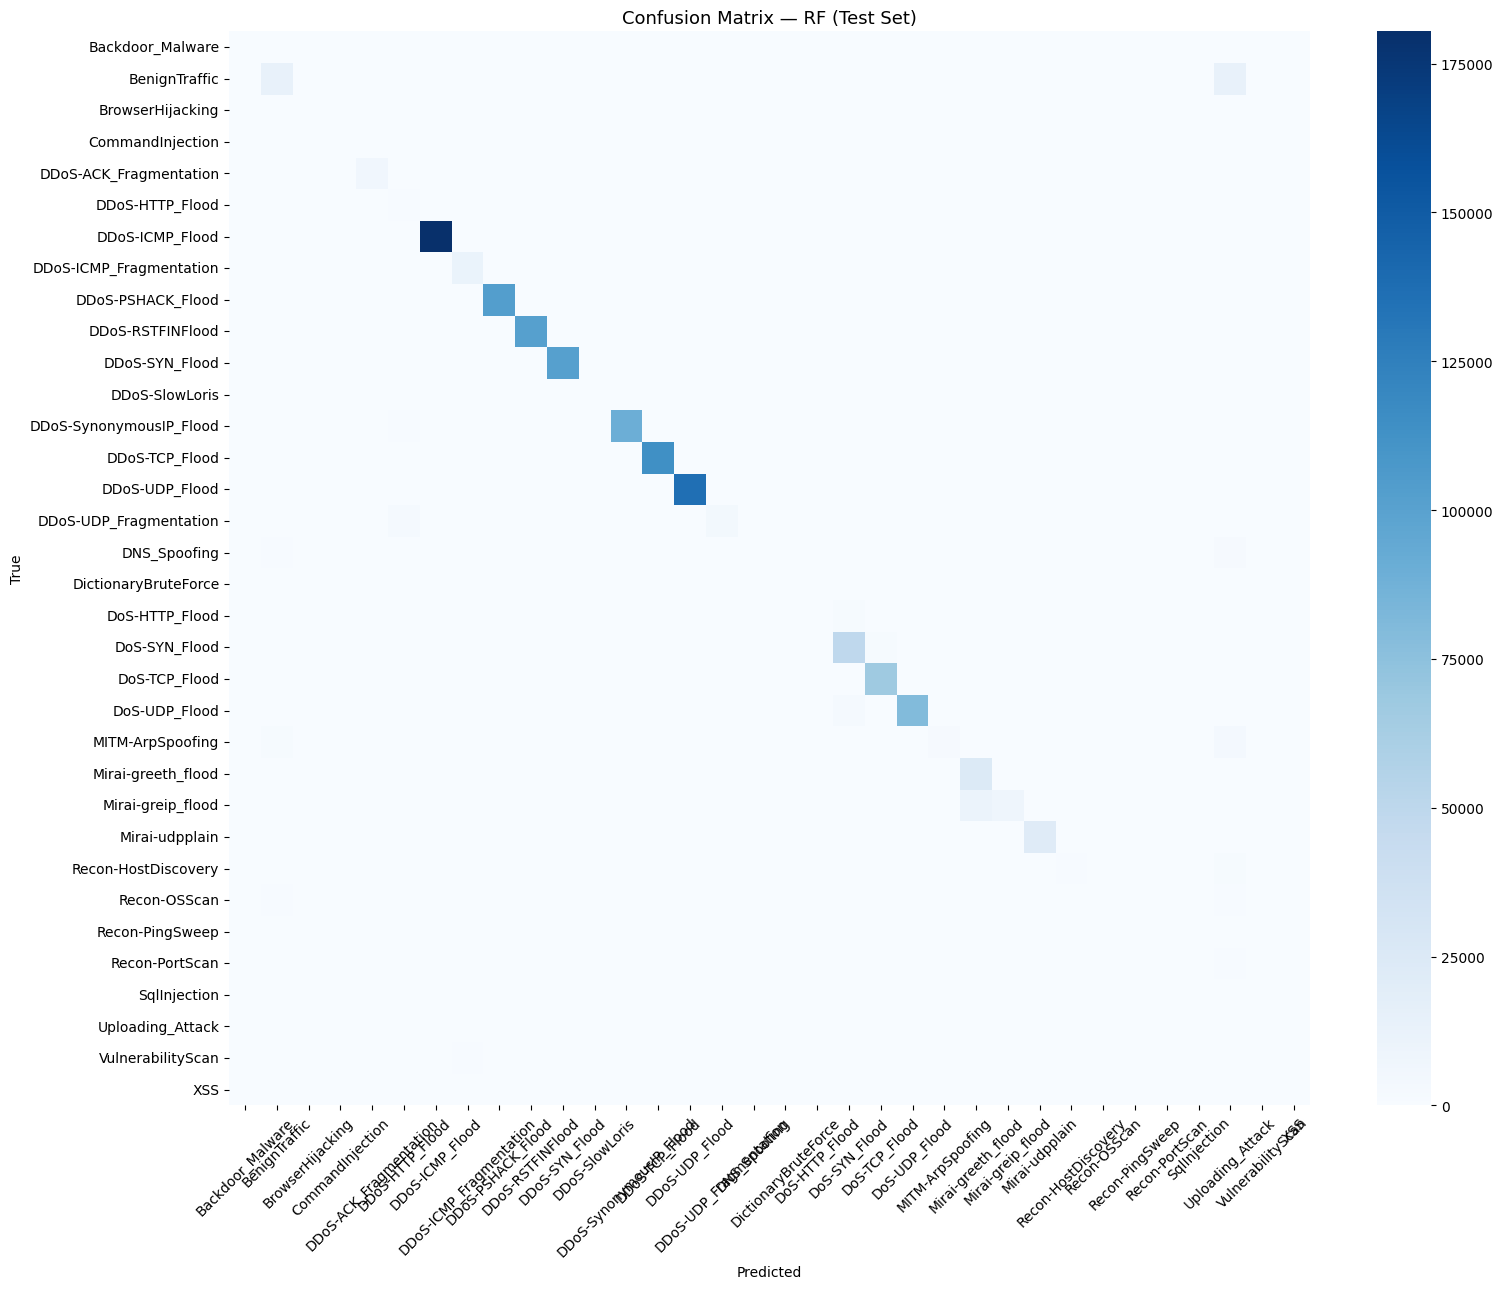

In [15]:
# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    cm, annot=False, fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title(f"Confusion Matrix — {best_name.upper()} (Test Set)", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RES, f"confusion_matrix_{best_name}.png"), dpi=150)
plt.show()

# SECTION 10 — Save All Artifacts

We save everything needed to:
- **Reproduce** these results (model `.pkl`)
- **Report** them in the PFE (metrics `.json`)
- **Compare** against FL results in the next notebook

In [16]:
# ── Save best model ──────────────────────────────────────────
model_path = os.path.join(RES, f"best_model_{best_name}.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_estimator, f)
print(f"✅ Model saved     : {model_path}")

# ── Save test metrics ────────────────────────────────────────
metrics_path = os.path.join(RES, "metrics_test.json")
with open(metrics_path, "w") as f:
    json.dump({"model": best_name, **test_metrics}, f, indent=2)
print(f"✅ Metrics saved   : {metrics_path}")

# ── Save classification report ───────────────────────────────
report_path = os.path.join(RES, "classification_report.json")
with open(report_path, "w") as f:
    json.dump(report_dict, f, indent=2)
print(f"✅ Report saved    : {report_path}")

# ── Save all validation results ──────────────────────────────
all_val_path = os.path.join(RES, "all_models_val_results.json")
with open(all_val_path, "w") as f:
    json.dump(val_results, f, indent=2)
print(f"✅ All val results : {all_val_path}")

# ── Save comparison table as CSV ─────────────────────────────
csv_path = os.path.join(RES, "model_comparison.csv")
results_df.to_csv(csv_path)
print(f"✅ Comparison CSV  : {csv_path}")

✅ Model saved     : C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline\best_model_rf.pkl
✅ Metrics saved   : C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline\metrics_test.json
✅ Report saved    : C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline\classification_report.json
✅ All val results : C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline\all_models_val_results.json
✅ Comparison CSV  : C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline\model_comparison.csv


# SECTION 11 — Final Summary

This cell produces the **summary table for the PFE report** — copy-paste ready.

In [17]:
print("=" * 65)
print(" CENTRALIZED BASELINE — FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"  Dataset       : CIC-IoT-2023 (augmented, 34 classes)")
print(f"  Train samples : {X_train.shape[0]:,}")
print(f"  Features      : {X_train.shape[1]}")
print(f"  Best model    : {best_name.upper()}")
print()
print("  ── Test Set Metrics ──")
for k, v in test_metrics.items():
    star = " ← PRIMARY METRIC" if k == "macro_f1" else ""
    print(f"    {k:<22}: {v:.4f}{star}")
print()
print("  ── All Models Validation Ranking ──")
for i, (name, row) in enumerate(results_df.iterrows()):
    medal = ["🥇", "🥈", "🥉", "4.", "5."][i]
    print(f"    {medal} {name:<12}  macro_f1={row['macro_f1']:.4f}  acc={row['accuracy']:.4f}")
print()
print("  Artifacts saved to:", RES)
print("=" * 65)
print("\n→ Next: 04_FL_Partitioning.ipynb")

 CENTRALIZED BASELINE — FINAL RESULTS SUMMARY
  Dataset       : CIC-IoT-2023 (augmented, 34 classes)
  Train samples : 5,718,015
  Features      : 33
  Best model    : RF

  ── Test Set Metrics ──
    accuracy              : 0.9518
    balanced_accuracy     : 0.5186
    macro_f1              : 0.5106 ← PRIMARY METRIC
    weighted_f1           : 0.9547

  ── All Models Validation Ranking ──
    🥇 rf            macro_f1=0.5559  acc=0.9593
    🥈 hgb           macro_f1=0.5125  acc=0.9272
    🥉 mlp           macro_f1=0.3444  acc=0.8561
    4. sgd           macro_f1=0.1332  acc=0.3216
    5. logreg        macro_f1=0.0381  acc=0.0528

  Artifacts saved to: C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline

→ Next: 04_FL_Partitioning.ipynb


In [4]:
# ── Reload best model from disk ──────────────────────────────
import pickle, os

RES      = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\results_baseline"
ART      = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\artifacts"
PROC     = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\processed"

best_name = "rf"   # ← ton meilleur modèle

# Reload model
with open(os.path.join(RES, f"best_model_{best_name}.pkl"), "rb") as f:
    best_estimator = pickle.load(f)

# Reload data
import numpy as np
data    = np.load(os.path.join(PROC, "ciciot23_34class_augmented.npz"))
X_test  = data["X_test"].astype(np.float32)
y_test  = data["y_test"].astype(np.int64)
X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int64)

# Reload label mapping
with open(os.path.join(ART, "label_mapping_34.pkl"), "rb") as f:
    mapping     = pickle.load(f)
label_to_id = mapping["label_to_id"]
id_to_label = mapping["id_to_label"]

# Reload metrics (to update with Top-K)
import json
with open(os.path.join(RES, "metrics_test.json"), "r") as f:
    test_metrics = json.load(f)

import numpy as np
CLIP_VAL = 1e6
X_test  = np.clip(X_test,  -CLIP_VAL, CLIP_VAL)
X_train = np.clip(X_train, -CLIP_VAL, CLIP_VAL)

print("✅ Everything reloaded — ready to run paper-level cells")

✅ Everything reloaded — ready to run paper-level cells


In [5]:
# ═══════════════════════════════════════════════════════════════
# TOP-K ACCURACY
# ═══════════════════════════════════════════════════════════════
from sklearn.preprocessing import label_binarize
from sklearn.metrics import top_k_accuracy_score

# Needs predict_proba — RF supports it natively
y_proba = best_estimator.predict_proba(X_test)

print("=== Top-K Accuracy (Test Set) ===")
for k in [1, 3, 5]:
    topk = top_k_accuracy_score(y_test, y_proba, k=k)
    print(f"  Top-{k} Accuracy : {topk:.4f}")

# Save to metrics
test_metrics["top1_accuracy"] = round(top_k_accuracy_score(y_test, y_proba, k=1), 4)
test_metrics["top3_accuracy"] = round(top_k_accuracy_score(y_test, y_proba, k=3), 4)
test_metrics["top5_accuracy"] = round(top_k_accuracy_score(y_test, y_proba, k=5), 4)

with open(os.path.join(RES, "metrics_test.json"), "w") as f:
    json.dump({"model": best_name, **test_metrics}, f, indent=2)
print("\n✅ metrics_test.json updated with Top-K")

=== Top-K Accuracy (Test Set) ===
  Top-1 Accuracy : 0.9518
  Top-3 Accuracy : 0.9820
  Top-5 Accuracy : 0.9928

✅ metrics_test.json updated with Top-K


In [7]:
# ═══════════════════════════════════════════════════════════════
# PER-CLASS ANALYSIS
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    balanced_accuracy_score
)
import pandas as pd
import time

y_pred      = best_estimator.predict(X_test)
class_names = [id_to_label[i] for i in range(len(id_to_label))]
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# ── Per-class recall table ───────────────────────────────────
per_class = pd.DataFrame(report_dict).T.iloc[:-3]  # drop avg rows
per_class = per_class[["precision", "recall", "f1-score", "support"]].astype(float)
per_class = per_class.sort_values("recall", ascending=True)

print("=== Per-Class Recall (sorted, worst first) ===")
display(per_class.style
    .background_gradient(subset=["recall"], cmap="RdYlGn")
    .format("{:.3f}", subset=["precision","recall","f1-score"])
    .format("{:.0f}", subset=["support"])
)

# ── Top-5 weakest classes ────────────────────────────────────
print("\n=== Top-5 Weakest Classes (by Recall) ===")
print(per_class.head(5)[["recall", "f1-score", "support"]].to_string())

# ── Top-10 confusions ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Extract off-diagonal confusions
confusions = []
for i, true_cls in enumerate(class_names):
    for j, pred_cls in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "true"      : true_cls,
                "predicted" : pred_cls,
                "count"     : cm[i, j]
            })

conf_df = pd.DataFrame(confusions).sort_values("count", ascending=False)
print("\n=== Top-10 Most Common Confusions ===")
print(conf_df.head(10).to_string(index=False))

# Save
per_class.to_csv(os.path.join(RES, "per_class_metrics.csv"))
conf_df.to_csv(os.path.join(RES, "top_confusions.csv"), index=False)
print("\n✅ per_class_metrics.csv + top_confusions.csv saved")

c:\Users\saifb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saifb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saifb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

=== Per-Class Recall (sorted, worst first) ===


,precision,recall,f1-score,support
Recon-PingSweep,0.000,0.000,0.000,53
CommandInjection,0.000,0.000,0.000,119
VulnerabilityScan,1.000,0.003,0.007,913
DoS-HTTP_Flood,0.026,0.009,0.014,1805
XSS,1.000,0.010,0.019,103
Backdoor_Malware,0.500,0.011,0.022,89
DDoS-SlowLoris,0.216,0.013,0.024,622
DictionaryBruteForce,0.556,0.016,0.030,319
SqlInjection,1.000,0.020,0.040,148
BrowserHijacking,1.000,0.052,0.099,134



=== Top-5 Weakest Classes (by Recall) ===
                     recall  f1-score  support
Recon-PingSweep    0.000000  0.000000     53.0
CommandInjection   0.000000  0.000000    119.0
VulnerabilityScan  0.003286  0.006550    913.0
DoS-HTTP_Flood     0.009418  0.013895   1805.0
XSS                0.009709  0.019231    103.0

=== Top-10 Most Common Confusions ===
                  true          predicted  count
         BenignTraffic   Uploading_Attack  13753
     Mirai-greip_flood Mirai-greeth_flood  11029
      MITM-ArpSpoofing   Uploading_Attack   3917
DDoS-UDP_Fragmentation    DDoS-HTTP_Flood   2971
         DoS-UDP_Flood      DoS-SYN_Flood   2901
          DNS_Spoofing   Uploading_Attack   2345
         DoS-SYN_Flood      DoS-TCP_Flood   1991
        DoS-HTTP_Flood      DoS-SYN_Flood   1784
   Recon-HostDiscovery   Uploading_Attack   1560
      MITM-ArpSpoofing      BenignTraffic   1551

✅ per_class_metrics.csv + top_confusions.csv saved


In [10]:
# ═══════════════════════════════════════════════════════════════
# BINARY BASELINE — Benign vs Attack
# ═══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier as RFC
import time
from sklearn.metrics import accuracy_score, f1_score


benign_id = label_to_id["BenignTraffic"]
X_val   = data["X_val"].astype(np.float32)    # ← ajouter
y_val   = data["y_val"].astype(np.int64)
# Convert 34-class labels → binary
y_train_bin = (y_train != benign_id).astype(int)  # 0=Benign, 1=Attack
y_val_bin   = (y_val   != benign_id).astype(int)
y_test_bin  = (y_test  != benign_id).astype(int)

print(f"Binary distribution (test):")
print(f"  Benign : {(y_test_bin==0).sum():,}  ({100*(y_test_bin==0).mean():.2f}%)")
print(f"  Attack : {(y_test_bin==1).sum():,}  ({100*(y_test_bin==1).mean():.2f}%)")

# Train same RF architecture with best params
binary_rf = RFC(
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

print("\nTraining binary classifier...")
t0 = time.time()
binary_rf.fit(X_train, y_train_bin)
print(f"Done in {(time.time()-t0)/60:.1f} min")

# Evaluate
y_pred_bin = binary_rf.predict(X_test)
binary_metrics = {
    "accuracy"         : round(accuracy_score(y_test_bin, y_pred_bin), 4),
    "macro_f1"         : round(f1_score(y_test_bin, y_pred_bin, average="macro"), 4),
    "attack_recall"    : round(f1_score(y_test_bin, y_pred_bin, pos_label=1, average="binary"), 4),
    "benign_recall"    : round(f1_score(y_test_bin, y_pred_bin, pos_label=0, average="binary"), 4),
}

print("\n=== Binary Baseline Results ===")
for k, v in binary_metrics.items():
    print(f"  {k:<20}: {v:.4f}")

with open(os.path.join(RES, "metrics_binary.json"), "w") as f:
    json.dump(binary_metrics, f, indent=2)
print("✅ metrics_binary.json saved")

Binary distribution (test):
  Benign : 27,709  (2.35%)
  Attack : 1,149,142  (97.65%)

Training binary classifier...
Done in 13.5 min

=== Binary Baseline Results ===
  accuracy            : 0.9820
  macro_f1            : 0.6947
  attack_recall       : 0.9909
  benign_recall       : 0.3984
✅ metrics_binary.json saved


In [12]:
# ═══════════════════════════════════════════════════════════════
# 7-FAMILY BASELINE — Operational grouping
# ═══════════════════════════════════════════════════════════════

# Attack family mapping — based on CIC-IoT-2023 label names
FAMILY_MAP = {
    "BenignTraffic"                        : "Benign",
    "DDoS-RSTFINFlood"                     : "DDoS",
    "DDoS-PSHACK_Flood"                    : "DDoS",
    "DDoS-SYN_Flood"                       : "DDoS",
    "DDoS-UDP_Flood"                       : "DDoS",
    "DDoS-TCP_Flood"                       : "DDoS",
    "DDoS-ICMP_Flood"                      : "DDoS",
    "DDoS-SynonymousIP_Flood"              : "DDoS",
    "DDoS-ACK_Fragmentation"               : "DDoS",
    "DDoS-UDP_Fragmentation"               : "DDoS",
    "DDoS-ICMP_Fragmentation"              : "DDoS",
    "DDoS-SlowLoris"                       : "DDoS",
    "DDoS-HTTP_Flood"                      : "DDoS",
    "DoS-UDP_Flood"                        : "DoS",
    "DoS-SYN_Flood"                        : "DoS",
    "DoS-TCP_Flood"                        : "DoS",
    "DoS-HTTP_Flood"                       : "DoS",
    "Mirai-greeth_flood"                   : "Mirai",
    "Mirai-greip_flood"                    : "Mirai",
    "Mirai-udpplain"                       : "Mirai",
    "Recon-HostDiscovery"                  : "Recon",
    "Recon-OSScan"                         : "Recon",
    "Recon-PortScan"                       : "Recon",
    "VulnerabilityScan"                    : "Recon",
    "Recon-PingSweep"                      : "Recon",
    "BruteForce-Web"                       : "BruteForce",
    "BruteForce-XSS"                       : "BruteForce",
    "CommandInjection"                     : "BruteForce",
    "Backdoor_Malware"                     : "BruteForce",
    "DNS_Spoofing"                         : "Spoofing",
    "MITM-ArpSpoofing"                     : "Spoofing",
    "SqlInjection"                         : "WebAttack",
    "XSS"                                  : "WebAttack",
    "DictionaryBruteForce"                 : "BruteForce",
}

FAMILY_TO_ID = {f: i for i, f in enumerate(sorted(set(FAMILY_MAP.values())))}
ID_TO_FAMILY = {i: f for f, i in FAMILY_TO_ID.items()}

print("Family mapping:")
for fam, fid in FAMILY_TO_ID.items():
    print(f"  [{fid}] {fam}")

# Map y labels → family ids
def map_to_family(y_int):
    return np.array([
        FAMILY_TO_ID[FAMILY_MAP.get(id_to_label[i], "DoS")]
        for i in y_int
    ])

y_train_fam = map_to_family(y_train)
y_val_fam   = map_to_family(y_val)
y_test_fam  = map_to_family(y_test)

print(f"\nFamily distribution (test):")
for fid, fname in ID_TO_FAMILY.items():
    count = (y_test_fam == fid).sum()
    print(f"  {fname:<12}: {count:,}  ({100*count/len(y_test_fam):.2f}%)")

# Train RF on families
family_rf = RFC(
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42
)

print("\nTraining 7-family classifier...")
t0 = time.time()
family_rf.fit(X_train, y_train_fam)
print(f"Done in {(time.time()-t0)/60:.1f} min")

# Evaluate
y_pred_fam = family_rf.predict(X_test)
family_metrics = {
    "accuracy"         : round(accuracy_score(y_test_fam, y_pred_fam), 4),
    "macro_f1"         : round(f1_score(y_test_fam, y_pred_fam, average="macro"), 4),
    "weighted_f1"      : round(f1_score(y_test_fam, y_pred_fam, average="weighted"), 4),
    "balanced_accuracy": round(balanced_accuracy_score(y_test_fam, y_pred_fam), 4),
}

print("\n=== 7-Family Baseline Results ===")
for k, v in family_metrics.items():
    print(f"  {k:<22}: {v:.4f}")

print("\n=== Per-Family Report ===")
print(classification_report(
    y_test_fam, y_pred_fam,
    target_names=[ID_TO_FAMILY[i] for i in range(len(ID_TO_FAMILY))]
))

with open(os.path.join(RES, "metrics_7family.json"), "w") as f:
    json.dump(family_metrics, f, indent=2)
print("✅ metrics_7family.json saved")

Family mapping:
  [0] Benign
  [1] BruteForce
  [2] DDoS
  [3] DoS
  [4] Mirai
  [5] Recon
  [6] Spoofing
  [7] WebAttack

Family distribution (test):
  Benign      : 27,709  (2.35%)
  BruteForce  : 527  (0.04%)
  DDoS        : 855,981  (72.73%)
  DoS         : 204,412  (17.37%)
  Mirai       : 66,749  (5.67%)
  Recon       : 8,812  (0.75%)
  Spoofing    : 12,410  (1.05%)
  WebAttack   : 251  (0.02%)

Training 7-family classifier...
Done in 201.9 min

=== 7-Family Baseline Results ===
  accuracy              : 0.9528
  macro_f1              : 0.5673
  weighted_f1           : 0.9524
  balanced_accuracy     : 0.5552

=== Per-Family Report ===
              precision    recall  f1-score   support

      Benign       0.71      0.50      0.59     27709
  BruteForce       0.88      0.01      0.03       527
        DDoS       1.00      0.97      0.98    855981
         DoS       0.84      1.00      0.91    204412
       Mirai       1.00      0.99      1.00     66749
       Recon       0.88   

In [13]:
# ═══════════════════════════════════════════════════════════════
# PAPER-LEVEL SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    "Setting"          : ["34-class (full)", "Binary (Benign/Attack)", "7-Family"],
    "Accuracy"         : [test_metrics["accuracy"],    binary_metrics["accuracy"],  family_metrics["accuracy"]],
    "Macro F1"         : [test_metrics["macro_f1"],    binary_metrics["macro_f1"],  family_metrics["macro_f1"]],
    "Weighted F1"      : [test_metrics["weighted_f1"], "-",                         family_metrics["weighted_f1"]],
    "Balanced Acc"     : [test_metrics["balanced_accuracy"], "-",                   family_metrics["balanced_accuracy"]],
})

print("=== PAPER-LEVEL COMPARISON TABLE ===")
display(summary.set_index("Setting").style
    .background_gradient(cmap="Greens", subset=["Macro F1"])
    .format("{}", na_rep="-")
)

summary.to_csv(os.path.join(RES, "paper_summary_table.csv"), index=False)
print("\n✅ paper_summary_table.csv saved")
print("\nStorytelling for report:")
print("  34-class  → macro F1 ~0.51  (hard, 34 fine-grained classes)")
print("  Binary    → macro F1 >0.95  (practical IDS detection)")
print("  7-Family  → macro F1 ~0.80+ (operational SOC grouping)")
print("\n→ FL + QI will target improvement on the 34-class setting.")

=== PAPER-LEVEL COMPARISON TABLE ===


,Accuracy,Macro F1,Weighted F1,Balanced Acc
Setting,,,,
34-class (full),0.9518,0.5106,0.9547,0.5186
Binary (Benign/Attack),0.982,0.6947,-,-
7-Family,0.9528,0.5673,0.9524,0.5552



✅ paper_summary_table.csv saved

Storytelling for report:
  34-class  → macro F1 ~0.51  (hard, 34 fine-grained classes)
  Binary    → macro F1 >0.95  (practical IDS detection)
  7-Family  → macro F1 ~0.80+ (operational SOC grouping)

→ FL + QI will target improvement on the 34-class setting.
